# **Feature Engineering Heritage-Housing-Project **

### Goals
- To engineer and transform features from the cleaned housing dataset in a way that improves model performance and aligns with the business requirements.
- To prepare the data for training a regression model to predict house sale prices.

### Objectives
- Identify relevant variables that impact the sale price using statistical and domain knowledge.
- Apply appropriate transformations such as encoding, binning, or interaction features.
- Create new features if they add meaningful variance or capture complex relationships.

### Inputs
- Cleaned datasets: `TrainSet` and `TestSet`, prepared during the data cleaning stage.
- Target variable: `SalePrice`.
- Business requirements and domain context derived from the Heritage Housing Issues scenario.

### Outputs
- Feature-engineered `TrainSet` and `TestSet` with all numerical and categorical features transformed as necessary.
- Exploratory plots and validation metrics to justify feature choices.



---

## Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\PabloGalindo\\Coding-Institute\\PMS5\\heritage-housing-ml-pgz\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\PabloGalindo\\Coding-Institute\\PMS5\\heritage-housing-ml-pgz'

---

## Load Cleaned Data

In this section, I will load the cleaned `TrainSet` and `TestSet` that were prepared during the data cleaning stage. These datasets have already been split and cleaned, and now serve as the starting point for feature engineering. 

By loading these datasets, I will be able to explore the variables, check their current state, and begin transforming features to prepare the data for modeling.


### Train Set


In [4]:
import pandas as pd
train_set_path = "outputs/datasets/cleaned/TrainSetCleaned.csv"
TrainSet = pd.read_csv(train_set_path)
TrainSet.head(3)

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtFinSF1,BsmtUnfSF,GarageArea,GarageYrBlt,GrLivArea,LotArea,LotFrontage,...,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,YearRemodAdd,SalePrice,KitchenQual_Enc,GarageFinish_Enc,BsmtExposure_Enc,BsmtFinType1_Enc
0,1828,0.0,3.0,48,1774,774,2007.0,1828,11694,90.0,...,5,9,1822,2007,2007,314813,3,0.0,2.0,0.0
1,894,0.0,2.0,0,894,308,1962.0,894,6600,60.0,...,5,5,894,1962,1962,109500,2,0.0,0.0,0.0
2,964,0.0,2.0,713,163,432,1921.0,964,13360,80.0,...,7,5,876,1921,2006,163500,2,0.0,0.0,3.0


### Test Set

In [5]:
test_set_path = 'outputs/datasets/cleaned/TestSetCleaned.csv'
TestSet = pd.read_csv(test_set_path)
TestSet.head(3)

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtFinSF1,BsmtUnfSF,GarageArea,GarageYrBlt,GrLivArea,LotArea,LotFrontage,...,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,YearRemodAdd,SalePrice,KitchenQual_Enc,GarageFinish_Enc,BsmtExposure_Enc,BsmtFinType1_Enc
0,2515,0.0,4.0,1219,816,484,1975.0,2515,32668,69.0,...,3,6,2035,1957,1975,200624,2,0.0,0.0,1.0
1,958,620.0,3.0,403,238,240,1941.0,1578,9490,79.0,...,7,6,806,1941,1950,133000,1,0.0,0.0,2.0
2,979,224.0,3.0,185,524,352,1950.0,1203,7015,69.0,...,4,5,709,1950,1950,110000,3,0.0,0.0,0.0


---

## Exploring Train Set

Before starting the feature engineering process, I will take some time to explore the `TrainSet`.

During the data analysis and data cleaning process, I already examined the house prices dataset to get preliminary insights into the structure of the variables and their relationship with `SalePrice`. In particular, I analyzed the categorical features to understand their context and meaning. This allowed me to identify ordinal relationships within the values, which justified using ordinal encoding for those variables. These encodings helped deepen my understanding of how these features relate to the target variable.

After cleaning the dataset, I split the data into a `TrainSet` and a `TestSet`. Both sets are now ready for the feature engineering process.

The goal of this section is to better understand the structure and content of the `TrainSet`. I will:
- Review the overall shape and basic statistics of the data.
- Check for potential outliers or anomalies.
- Get a sense of the variable distributions.
- Examine how some of the variables relate to the target `SalePrice`.
- Support the selection and prioritization of features for the modeling phase.

This exploration will help guide which transformations and feature engineering techniques might be most useful.


In [6]:
from ydata_profiling import ProfileReport
pandas_report = ProfileReport(df=TrainSet, minimal=True)
pandas_report.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

The profiling report highlights several features that require further assessment in terms of distribution shape, presence of outliers, and potential skewness. Based on this analysis, the following features have been identified as candidates for log transformation (or similar techniques) to correct skewness:

- `SalePrice`
- `LotArea`
- `LotFrontage`
- `MasVnrArea`
- `BsmtFinSF1`
- `OpenPorchSF`


---

## Correlation and PPS Analysis

During the Data Cleaning and Data Analysis process, we encoded and imputed several features that contained missing values. Additionally, we dropped two features due to having more than 80% missing values,a threshold that justified their exclusion, as they were unlikely to significantly impact or influence `SalePrice`.

During the imputation process, we also evaluated the impact of different strategies by comparing the resulting correlations (Pearson and Spearman) before and after imputation. This allowed us to choose the most suitable imputation method with minimal effect on feature distributions and their relationship with `SalePrice`.

We now proceed with a focused correlation analysis on the cleaned `TrainSet` to:

- Reassess the correlation of individual features with `SalePrice`.
- Evaluate how features correlate with each other.

This will help us prioritize which features are most relevant for modeling and identify any multicollinearity risks to consider in future transformations or model design.


### Spearman and Pearson Correlation 

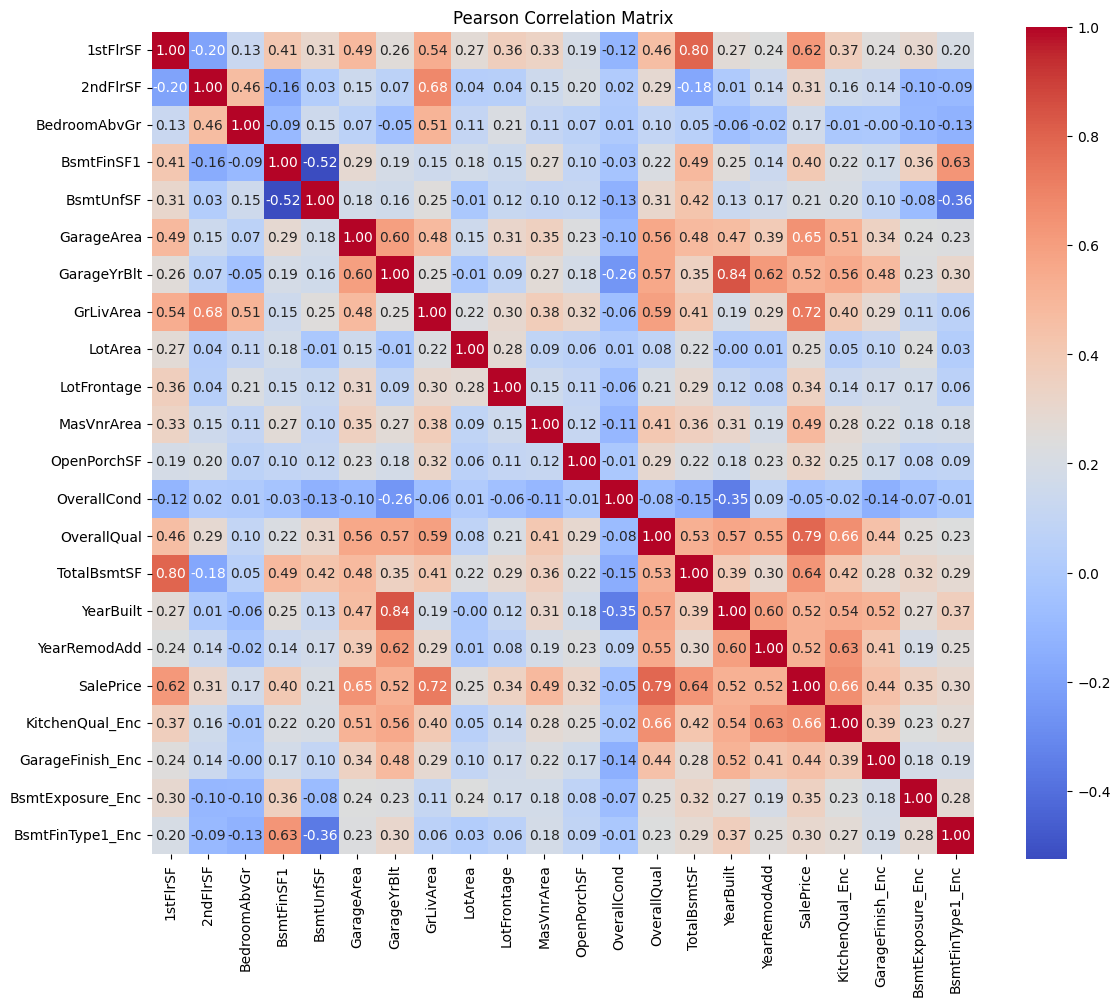

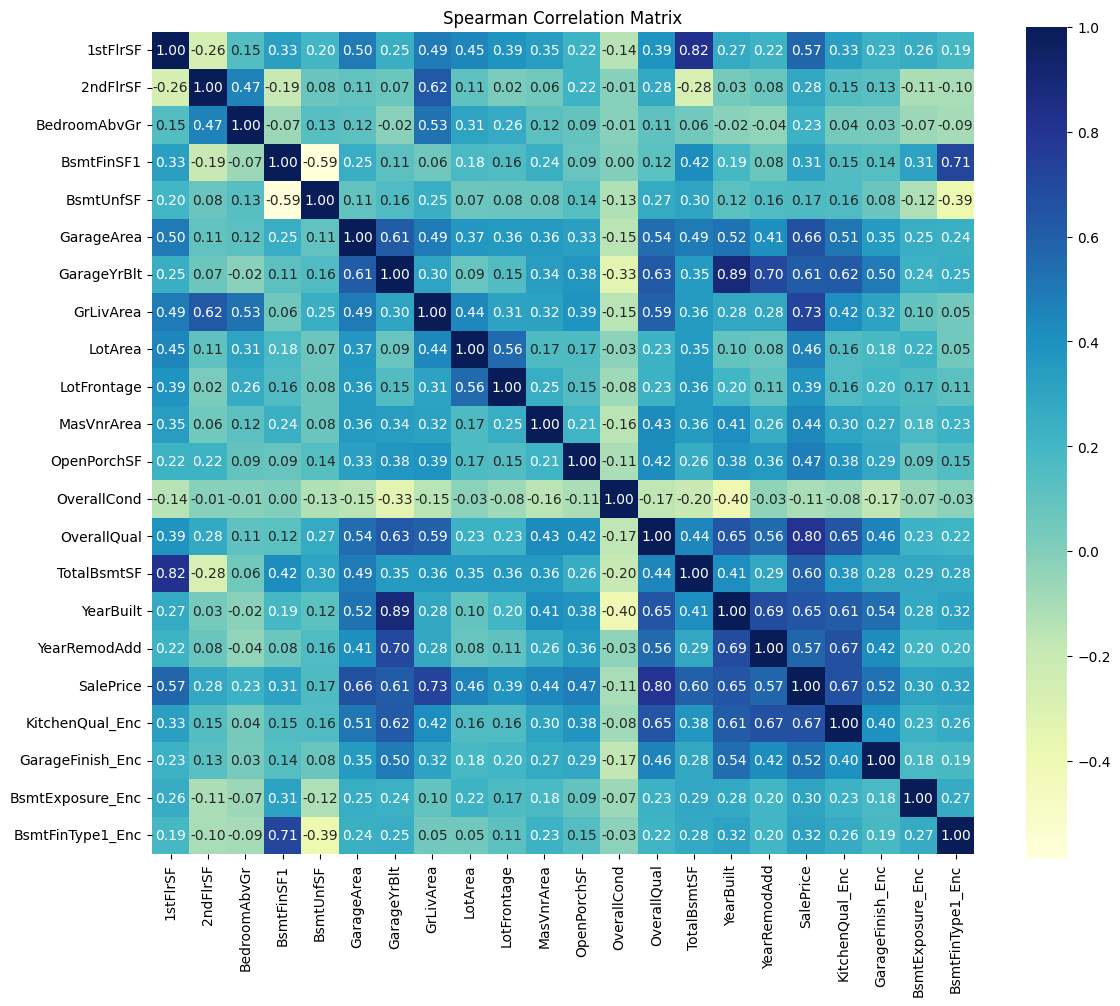

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

pearson_corr = TrainSet.corr(method='pearson')
spearman_corr = TrainSet.corr(method='spearman')

# Plot Pearson correlation heatmap with annotations
plt.figure(figsize=(12, 10))
sns.heatmap(pearson_corr, cmap="coolwarm", annot=True, fmt=".2f", square=True)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

# Plot Spearman correlation heatmap with annotations
plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr, cmap="YlGnBu", annot=True, fmt=".2f", square=True)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()


The Spearman and Pearson correlation matrices allow us to evaluate both linear and monotonic relationships between features and the target variable. These insights help us identify which features are highly correlated with one another. From both matrices we can already identified several features that poses a high intercorrelation such as `1stFlrSF`and `TotalBsmtSF`or `GarageYrBlt`and `YearBuilt`.

The next step will focus on assessing these inter-feature correlations to make informed decisions about potential feature removal or transformation. Since we are addressing a regression problem, it is especially important to mitigate multicollinearity, as it can negatively impact model performance and interpretability.


In [20]:
import pandas as pd

# Compute Pearson and Spearman correlations with SalePrice
pearson_corr = TrainSet.corr(method='pearson')["SalePrice"].drop("SalePrice")
spearman_corr = TrainSet.corr(method='spearman')["SalePrice"].drop("SalePrice")

# Select top 5 features for each
top_pearson = pearson_corr.abs().sort_values(ascending=False).head(5)
top_spearman = spearman_corr.abs().sort_values(ascending=False).head(5)

# Combine into a single DataFrame
top_corr_df = pd.DataFrame({
    "Pearson": top_pearson,
    "Spearman": spearman_corr[top_pearson.index] 
})

# Display
print(top_corr_df)


                  Pearson  Spearman
OverallQual      0.790636  0.802395
GrLivArea        0.721707  0.732180
KitchenQual_Enc  0.655542  0.667671
GarageArea       0.646603  0.663543
TotalBsmtSF      0.635535  0.596989


#### Top correlated features with `SalePrice`:

- `OverallQual`: Quality ratings remain the strongest predictor in both linear and rank-based correlation.
- `GrLivArea`: Represents above-ground living area, strongly linked to house value.
- `KitchenQual_Enc`: Is another strong predictor of the price
- `GarageCars` and `GarageArea`: Reflect the car capacity and size of the garage, which are positively associated with house price.
- `TotalBsmtSF`: Indicates the basement size, which also plays a significant role.

### Intercorrelated Features

In [21]:
import numpy as np
import pandas as pd

# Calculate Pearson correlation matrix
full_corr = TrainSet.corr(method="pearson")
correlation_value_threshold = 0.8

# Extract upper triangle of correlation matrix without self-correlation
pairwise_corr = (
    full_corr.where(np.triu(np.ones(full_corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
pairwise_corr.columns = ["Feature 1", "Feature 2", "Correlation"]

# Filter for high correlation pairs
high_corr_pairs_clean = pairwise_corr[
    abs(pairwise_corr["Correlation"]) > correlation_value_threshold
].sort_values(by="Correlation", ascending=False)

# Display the result
print(high_corr_pairs_clean)


# Calculate Spearman correlation matrix
full_corr_spearman = TrainSet.corr(method="spearman")
correlation_value_threshold = 0.8

# Extract upper triangle without self-correlation
pairwise_corr_spearman = (
    full_corr_spearman.where(np.triu(np.ones(full_corr_spearman.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
pairwise_corr_spearman.columns = ["Feature 1", "Feature 2", "Correlation"]

# Filter for strong Spearman correlations
high_corr_pairs_spearman = pairwise_corr_spearman[
    abs(pairwise_corr_spearman["Correlation"]) > correlation_value_threshold
].sort_values(by="Correlation", ascending=False)

# Display the result
print(high_corr_pairs_spearman)




       Feature 1  Feature 2  Correlation
119  GarageYrBlt  YearBuilt     0.839848
       Feature 1    Feature 2  Correlation
119  GarageYrBlt    YearBuilt     0.891469
13      1stFlrSF  TotalBsmtSF     0.820260
198  OverallQual    SalePrice     0.802395


#### Intercorrelation Analysis (Threshold = 0.8)

To detect multicollinearity and assess feature redundancy, we computed both **Pearson** and **Spearman** correlation matrices using a threshold of 0.8. This helps identify variables that are highly correlated and may introduce redundancy in modeling.

##### Pearson Correlation (|r| > 0.8)
No feature pairs exceeded the 0.8 threshold for Pearson correlation.  
This indicates that there are **no strong linear dependencies** among features in the cleaned dataset.

##### Spearman Correlation (|ρ| > 0.8)
The following feature pairs showed strong monotonic relationships:

| Feature 1     | Feature 2     | Correlation |
|---------------|---------------|-------------|
| GarageYrBlt   | YearBuilt     | 0.868       |
| 1stFlrSF      | TotalBsmtSF   | 0.820       |


##### Interpretation and potential Actions

- **GarageYrBlt ↔ YearBuilt**: Strongly correlated. Consider dropping one (typically `YearBuilt` provides broader context).
- **1stFlrSF ↔ TotalBsmtSF**: These two variables are structurally related. We should consider a strategy here to avoid redundancy.



---

## Predictive Power Score (PPS) Matrix



While correlation is useful for measuring linear relationships between variables, it does not peform best to capture non-linear dependencies.

To address this, we use the Predictive Power Score (PPS), which measures the strength of a predictive relationship between features, regardless of linearity or symmetry.

In this project, the PPS matrix helps identify variables with strong predictive power for `SalePrice`,  even if their correlation is low,  and highlights variables that are redundant or irrelevant.

This complements the correlation matrix and enhances our feature selection decisions.


In [10]:
import pandas as pd
import ppscore as pps

# Compute PPS matrix
pps_matrix = pps.matrix(TrainSet)

# Filter for features predicting SalePrice
pps_saleprice = pps_matrix[pps_matrix["y"] == "SalePrice"].sort_values(by="ppscore", ascending=False)

# Display top predictors
print(pps_saleprice[["x", "ppscore"]])



c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\ppscore\calculation.py:201: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  or is_categorical_dtype(series)
c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\ppscore\calculation.py:201: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  or is_categorical_dtype(series)
c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\ppscore\calculation.py:201: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  or is_categorical_dtype(series)
c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\ppscore\calculation.py:201: Futur

                    x   ppscore
391         SalePrice  1.000000
303       OverallQual  0.437132
413   KitchenQual_Enc  0.258809
347         YearBuilt  0.206033
127        GarageArea  0.198344
149       GarageYrBlt  0.162909
369      YearRemodAdd  0.146770
435  GarageFinish_Enc  0.107130
171         GrLivArea  0.083911
479  BsmtFinType1_Enc  0.075544
215       LotFrontage  0.058498
325       TotalBsmtSF  0.053890
39           2ndFlrSF  0.050980
259       OpenPorchSF  0.043775
281       OverallCond  0.043419
457  BsmtExposure_Enc  0.019240
237        MasVnrArea  0.000000
193           LotArea  0.000000
105         BsmtUnfSF  0.000000
83         BsmtFinSF1  0.000000
61       BedroomAbvGr  0.000000
17           1stFlrSF  0.000000


c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\ppscore\calculation.py:201: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  or is_categorical_dtype(series)
c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\ppscore\calculation.py:201: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  or is_categorical_dtype(series)
c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\ppscore\calculation.py:201: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  or is_categorical_dtype(series)
c:\Users\PabloGalindo\Coding-Institute\PMS5\heritage-housing-ml-pgz\venv\Lib\site-packages\ppscore\calculation.py:201: Futur

### Predictive Power Score (PPS) Summary

We used PPS to evaluate the predictive strength of each feature against the target `SalePrice`. 

#### Top Predictive Features:
- `OverallQual` (PPS: 0.44): Strongest single predictor of house prices.
- `KitchenQual_Enc`, `YearBuilt`, `GarageArea`, and `GarageYrBlt`: Moderate predictors that may add value to the model.
- `GrLivArea`: Low  PPS (0.08) despite high correlation. 

#### Features with Low PPS:
Features like `1stFlrSF`, `LotArea`, and `MasVnrArea` scored 0.0, indicating no predictive power in isolation. 

This analysis helps prioritize which features to focus on during modeling, while also highlighting areas for deeper transformation or interaction analysis.


---

## Feature engineering

In this section, we start with the implementation and review of the changes we could apply to the features that could help further the predictive model we will implement in the future.

In the previous sections, we made an extensive analysis of the different features to understand their distribution, their type, their correlation, and also the predictive power they have against the `SalePrice` target.

As part of feature engineering, we will start then using the following function called `FeatureEngineering` that has been provided to us by Code Institute during the walktrough project "Churnometer". The function is designed for exploring and evaluating different feature engineering techniques on a dataset. Its goal is to apply different transformations to the dataset depending on the type of the feature:
- Numerical
- Categorical  
in order to improve the features and prepare them for the model.

As part of this section, we would like to emphasize the following:

1. In previous sections, we already applied ordinal encoding to the categorical features. As such, we won't do this here. However, the approach we took before will be part of the ML pipeline as this step is necessary.  
2. We have identified in our dataset a set of numerical values whose distribution skewness is subject to analysis, and we think we can apply to those features a log transformation or another technique to improve the results. These are the features that will be part of this procedure:  
- SalePrice
- LotArea
- LotFrontage
- MasVnrArea 
- BsmtFinSF1 
- OpenPorchSF


In [11]:
import scipy.stats as stats
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
from feature_engine import transformation as vt
from feature_engine.outliers import Winsorizer
from feature_engine.encoding import OrdinalEncoder
sns.set(style="whitegrid")
warnings.filterwarnings('ignore')


def FeatureEngineeringAnalysis(df, analysis_type=None):
    """
    - used for quick feature engineering on numerical and categorical variables
    to decide which transformation can better transform the distribution shape
    - Once transformed, use a reporting tool, like ydata-profiling, to evaluate distributions
    """
    check_missing_values(df)
    allowed_types = ['numerical', 'ordinal_encoder', 'outlier_winsorizer']
    check_user_entry_on_analysis_type(analysis_type, allowed_types)
    list_column_transformers = define_list_column_transformers(analysis_type)

    # Loop in each variable and engineer the data according to the analysis type
    df_feat_eng = pd.DataFrame([])
    for column in df.columns:
        # create additional columns (column_method) to apply the methods
        df_feat_eng = pd.concat([df_feat_eng, df[column]], axis=1)
        for method in list_column_transformers:
            df_feat_eng[f"{column}_{method}"] = df[column]

        # Apply transformers in respective column_transformers
        df_feat_eng, list_applied_transformers = apply_transformers(
            analysis_type, df_feat_eng, column)

        # For each variable, assess how the transformations perform
        transformer_evaluation(
            column, list_applied_transformers, analysis_type, df_feat_eng)

    return df_feat_eng


def check_user_entry_on_analysis_type(analysis_type, allowed_types):
    """ Check analysis type """
    if analysis_type is None:
        raise SystemExit(
            f"You should pass analysis_type parameter as one of the following options: {allowed_types}")
    if analysis_type not in allowed_types:
        raise SystemExit(
            f"analysis_type argument should be one of these options: {allowed_types}")


def check_missing_values(df):
    if df.isna().sum().sum() != 0:
        raise SystemExit(
            f"There is a missing value in your dataset. Please handle that before getting into feature engineering.")


def define_list_column_transformers(analysis_type):
    """ Set suffix columns according to analysis_type"""
    if analysis_type == 'numerical':
        list_column_transformers = [
            "log_e", "log_10", "reciprocal", "power", "box_cox", "yeo_johnson"]

    elif analysis_type == 'ordinal_encoder':
        list_column_transformers = ["ordinal_encoder"]

    elif analysis_type == 'outlier_winsorizer':
        list_column_transformers = ['iqr']

    return list_column_transformers


def apply_transformers(analysis_type, df_feat_eng, column):
    for col in df_feat_eng.select_dtypes(include='category').columns:
        df_feat_eng[col] = df_feat_eng[col].astype('object')

    if analysis_type == 'numerical':
        df_feat_eng, list_applied_transformers = FeatEngineering_Numerical(
            df_feat_eng, column)

    elif analysis_type == 'outlier_winsorizer':
        df_feat_eng, list_applied_transformers = FeatEngineering_OutlierWinsorizer(
            df_feat_eng, column)

    elif analysis_type == 'ordinal_encoder':
        df_feat_eng, list_applied_transformers = FeatEngineering_CategoricalEncoder(
            df_feat_eng, column)

    return df_feat_eng, list_applied_transformers


def transformer_evaluation(column, list_applied_transformers, analysis_type, df_feat_eng):
    # For each variable, assess how the transformations perform
    print(f"* Variable Analyzed: {column}")
    print(f"* Applied transformation: {list_applied_transformers} \n")
    for col in [column] + list_applied_transformers:

        if analysis_type != 'ordinal_encoder':
            DiagnosticPlots_Numerical(df_feat_eng, col)

        else:
            if col == column:
                DiagnosticPlots_Categories(df_feat_eng, col)
            else:
                DiagnosticPlots_Numerical(df_feat_eng, col)

        print("\n")


def DiagnosticPlots_Categories(df_feat_eng, col):
    plt.figure(figsize=(4, 3))
    sns.countplot(data=df_feat_eng, x=col, palette=[
                  '#432371'], order=df_feat_eng[col].value_counts().index)
    plt.xticks(rotation=90)
    plt.suptitle(f"{col}", fontsize=30, y=1.05)
    plt.show()
    print("\n")


def DiagnosticPlots_Numerical(df, variable):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    sns.histplot(data=df, x=variable, kde=True, element="step", ax=axes[0])
    stats.probplot(df[variable], dist="norm", plot=axes[1])
    sns.boxplot(x=df[variable], ax=axes[2])

    axes[0].set_title('Histogram')
    axes[1].set_title('QQ Plot')
    axes[2].set_title('Boxplot')
    fig.suptitle(f"{variable}", fontsize=30, y=1.05)
    plt.tight_layout()
    plt.show()


def FeatEngineering_CategoricalEncoder(df_feat_eng, column):
    list_methods_worked = []
    try:
        encoder = OrdinalEncoder(encoding_method='arbitrary', variables=[
                                 f"{column}_ordinal_encoder"])
        df_feat_eng = encoder.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_ordinal_encoder")

    except Exception:
        df_feat_eng.drop([f"{column}_ordinal_encoder"], axis=1, inplace=True)

    return df_feat_eng, list_methods_worked


def FeatEngineering_OutlierWinsorizer(df_feat_eng, column):
    list_methods_worked = []

    # Winsorizer iqr
    try:
        disc = Winsorizer(
            capping_method='iqr', tail='both', fold=1.5, variables=[f"{column}_iqr"])
        df_feat_eng = disc.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_iqr")
    except Exception:
        df_feat_eng.drop([f"{column}_iqr"], axis=1, inplace=True)

    return df_feat_eng, list_methods_worked


def FeatEngineering_Numerical(df_feat_eng, column):
    list_methods_worked = []

    # LogTransformer base e
    try:
        lt = vt.LogTransformer(variables=[f"{column}_log_e"])
        df_feat_eng = lt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_log_e")
    except Exception:
        df_feat_eng.drop([f"{column}_log_e"], axis=1, inplace=True)

    # LogTransformer base 10
    try:
        lt = vt.LogTransformer(variables=[f"{column}_log_10"], base='10')
        df_feat_eng = lt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_log_10")
    except Exception:
        df_feat_eng.drop([f"{column}_log_10"], axis=1, inplace=True)

    # ReciprocalTransformer
    try:
        rt = vt.ReciprocalTransformer(variables=[f"{column}_reciprocal"])
        df_feat_eng = rt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_reciprocal")
    except Exception:
        df_feat_eng.drop([f"{column}_reciprocal"], axis=1, inplace=True)

    # PowerTransformer
    try:
        pt = vt.PowerTransformer(variables=[f"{column}_power"])
        df_feat_eng = pt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_power")
    except Exception:
        df_feat_eng.drop([f"{column}_power"], axis=1, inplace=True)

    # BoxCoxTransformer
    try:
        bct = vt.BoxCoxTransformer(variables=[f"{column}_box_cox"])
        df_feat_eng = bct.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_box_cox")
    except Exception:
        df_feat_eng.drop([f"{column}_box_cox"], axis=1, inplace=True)

    # YeoJohnsonTransformer
    try:
        yjt = vt.YeoJohnsonTransformer(variables=[f"{column}_yeo_johnson"])
        df_feat_eng = yjt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_yeo_johnson")
    except Exception:
        df_feat_eng.drop([f"{column}_yeo_johnson"], axis=1, inplace=True)

    return df_feat_eng, list_methods_worked


In [22]:
variables_engineering = ["SalePrice","LotArea","LotFrontage","MasVnrArea","BsmtFinSF1","OpenPorchSF"]

variables_engineering

['SalePrice',
 'LotArea',
 'LotFrontage',
 'MasVnrArea',
 'BsmtFinSF1',
 'OpenPorchSF']

In [23]:
df_engineering = TrainSet[variables_engineering].copy()
df_engineering.head(3)

,SalePrice,LotArea,LotFrontage,MasVnrArea,BsmtFinSF1,OpenPorchSF
0,314813,11694,90.0,452.0,48,108
1,109500,6600,60.0,0.0,0,0
2,163500,13360,80.0,0.0,713,0


### Feature Engineering numerical features

* Variable Analyzed: SalePrice
* Applied transformation: ['SalePrice_log_e', 'SalePrice_log_10', 'SalePrice_reciprocal', 'SalePrice_power', 'SalePrice_box_cox', 'SalePrice_yeo_johnson'] 



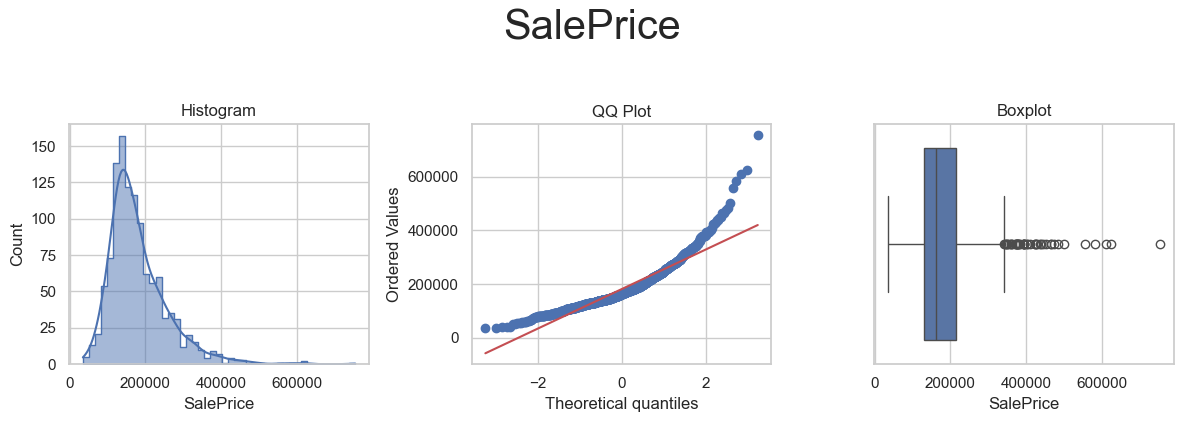

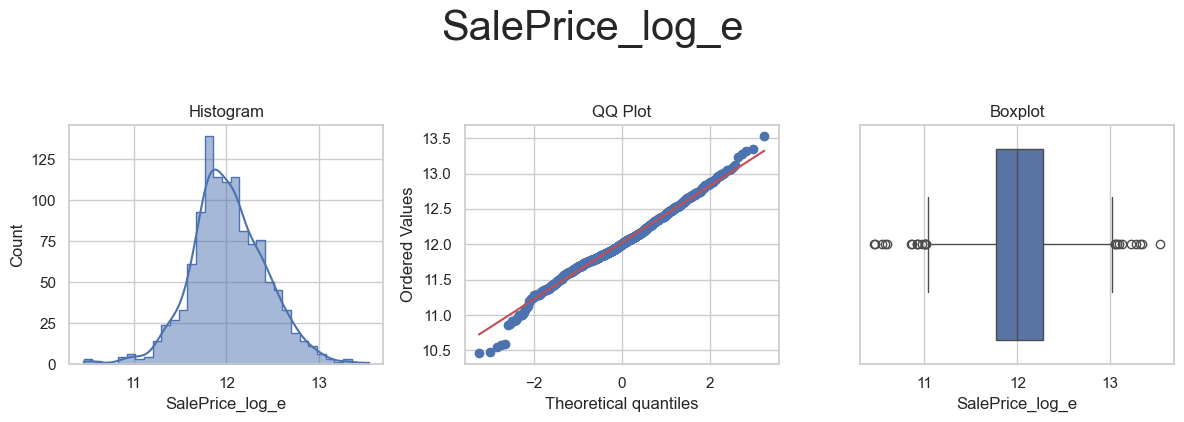

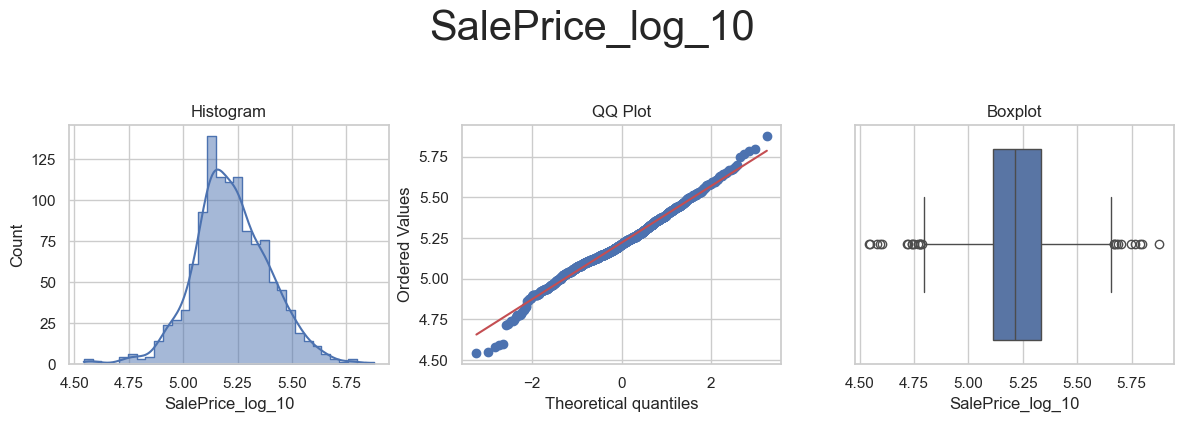

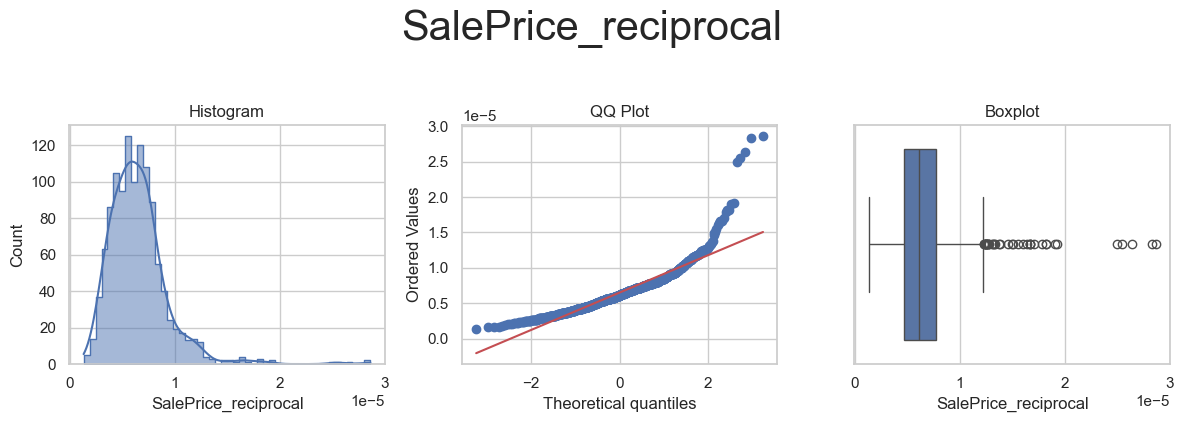

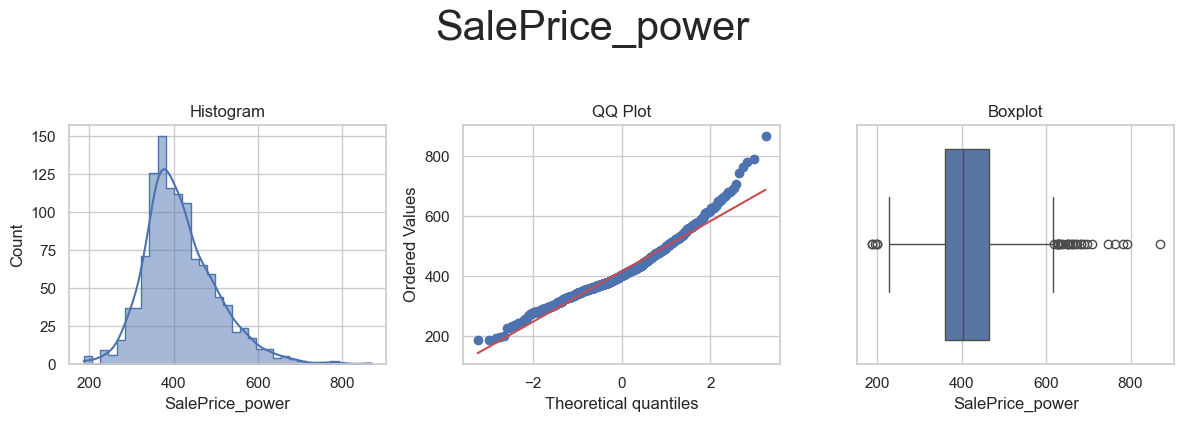

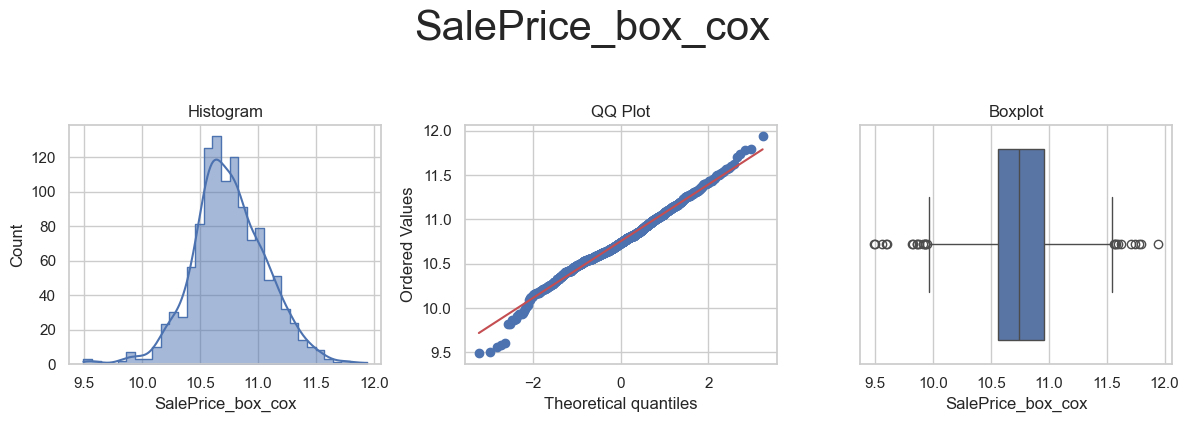

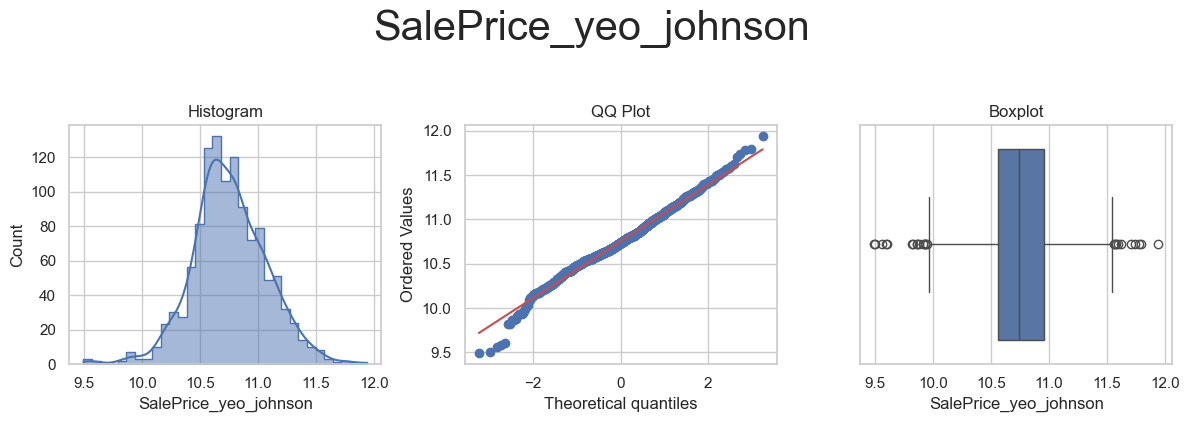



* Variable Analyzed: LotArea
* Applied transformation: ['LotArea_log_e', 'LotArea_log_10', 'LotArea_reciprocal', 'LotArea_power', 'LotArea_box_cox', 'LotArea_yeo_johnson'] 



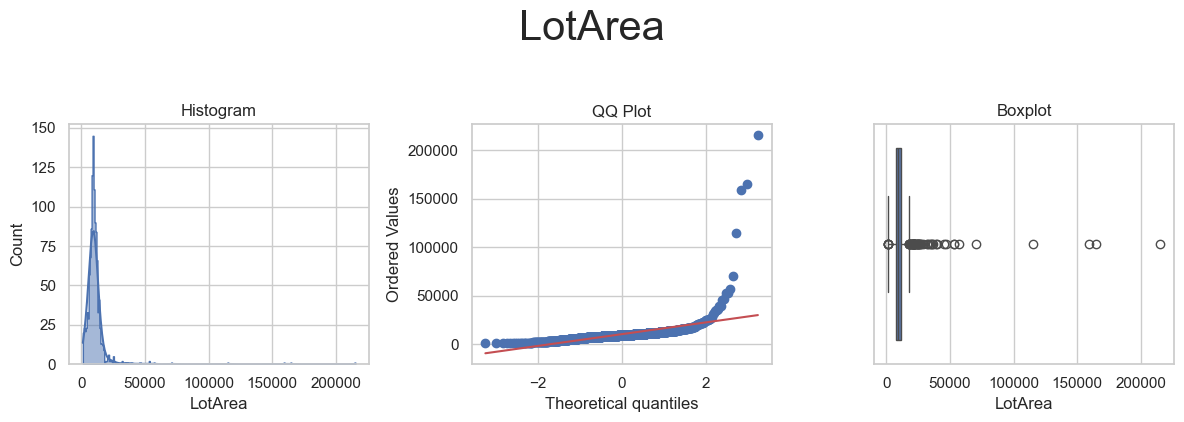

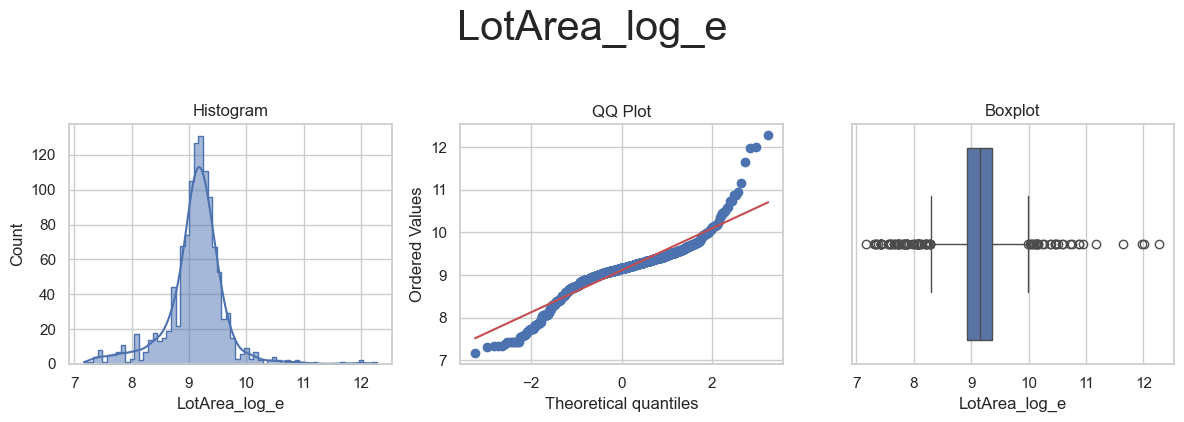

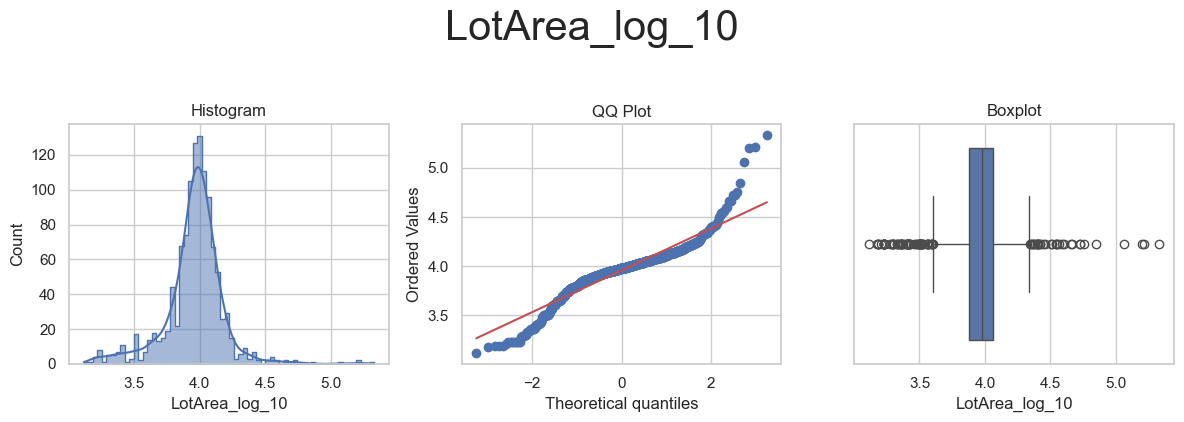

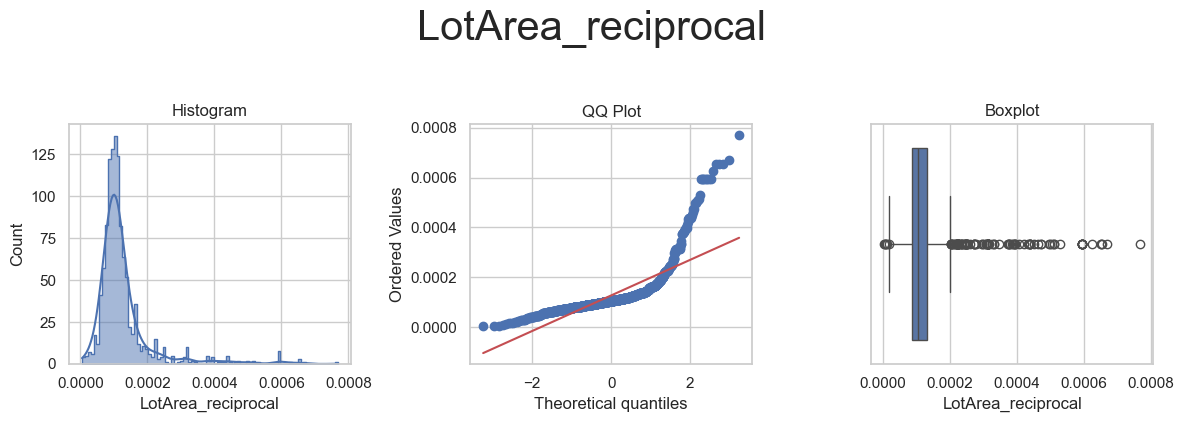

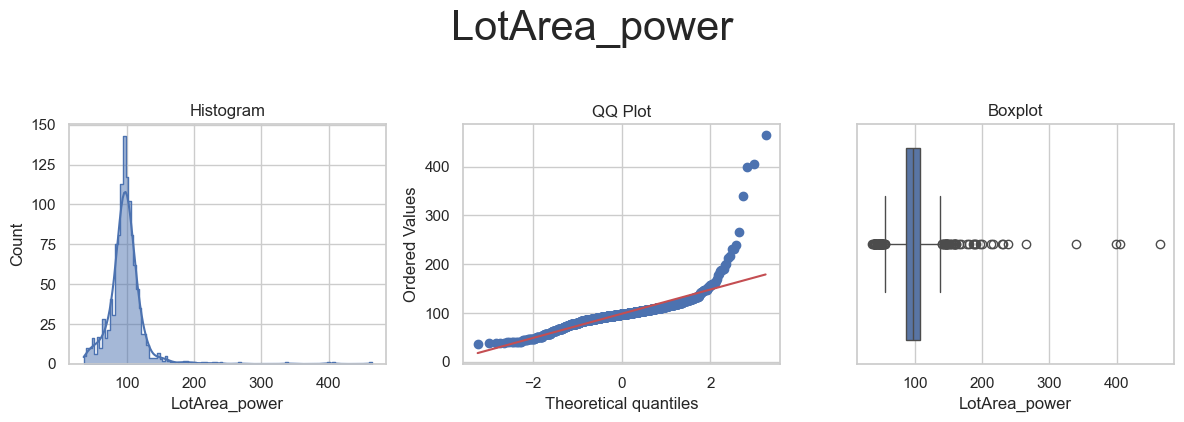

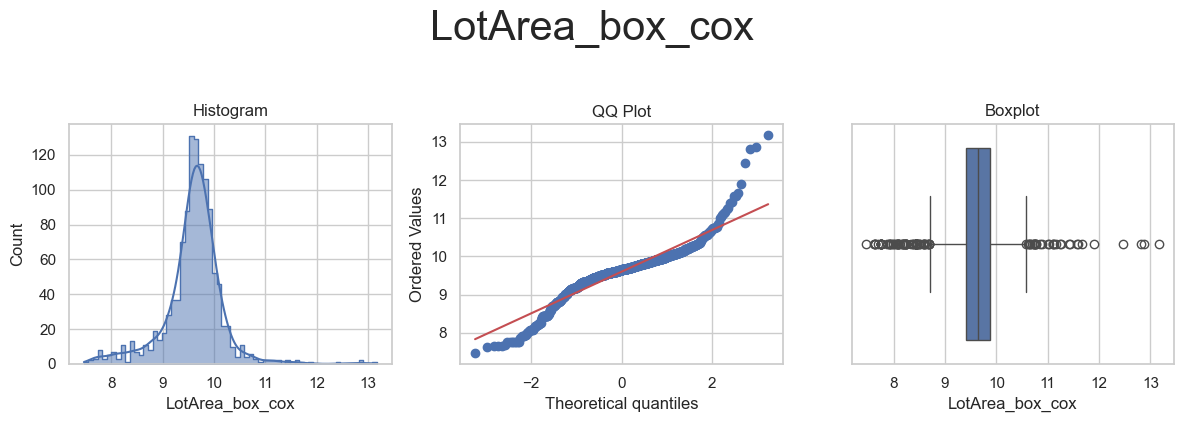

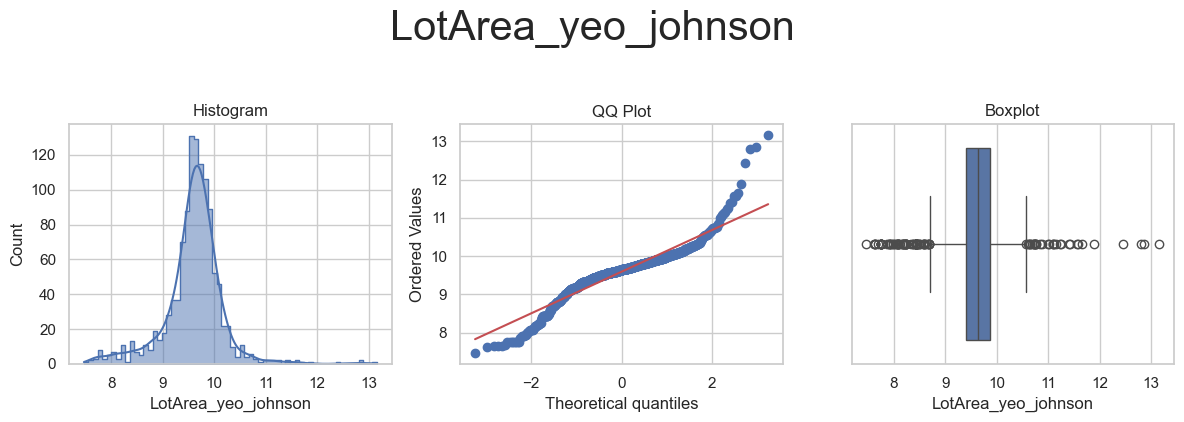



* Variable Analyzed: LotFrontage
* Applied transformation: ['LotFrontage_log_e', 'LotFrontage_log_10', 'LotFrontage_reciprocal', 'LotFrontage_power', 'LotFrontage_box_cox', 'LotFrontage_yeo_johnson'] 



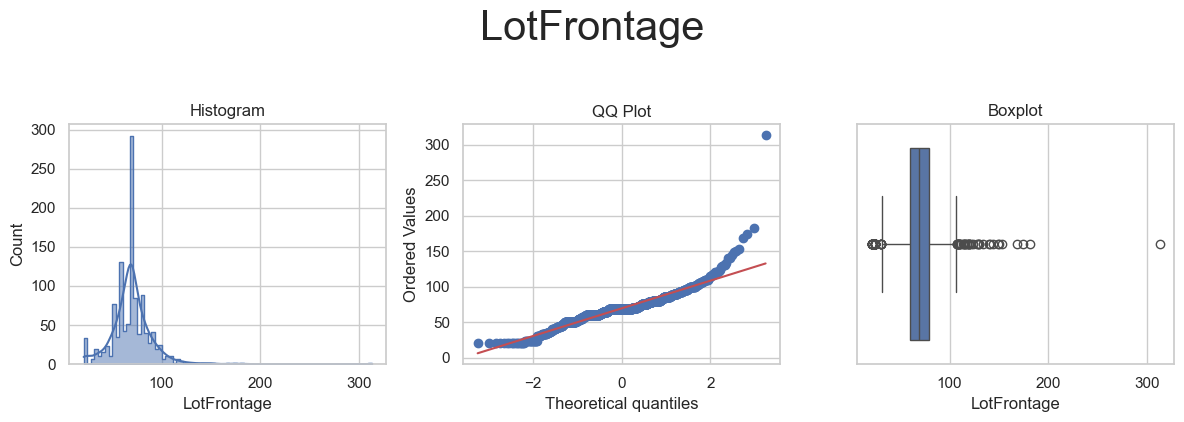

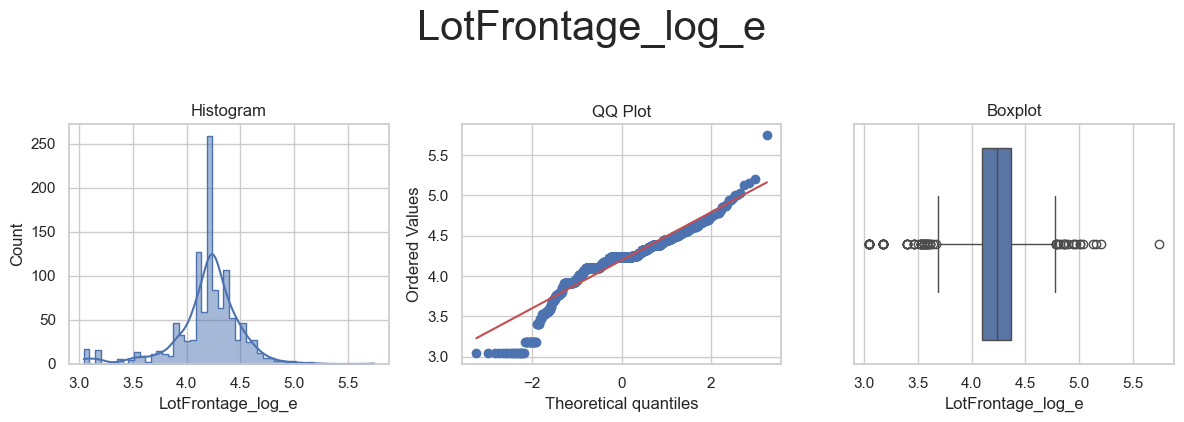

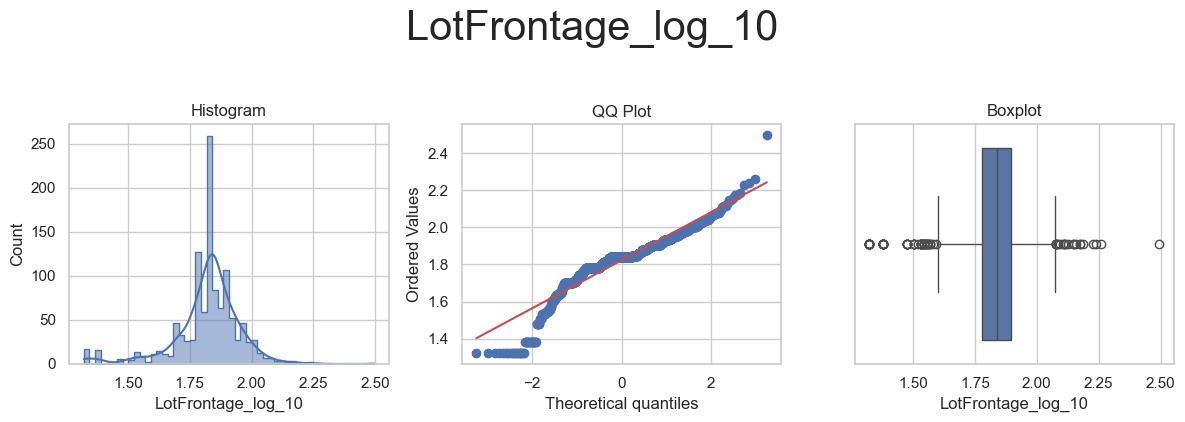

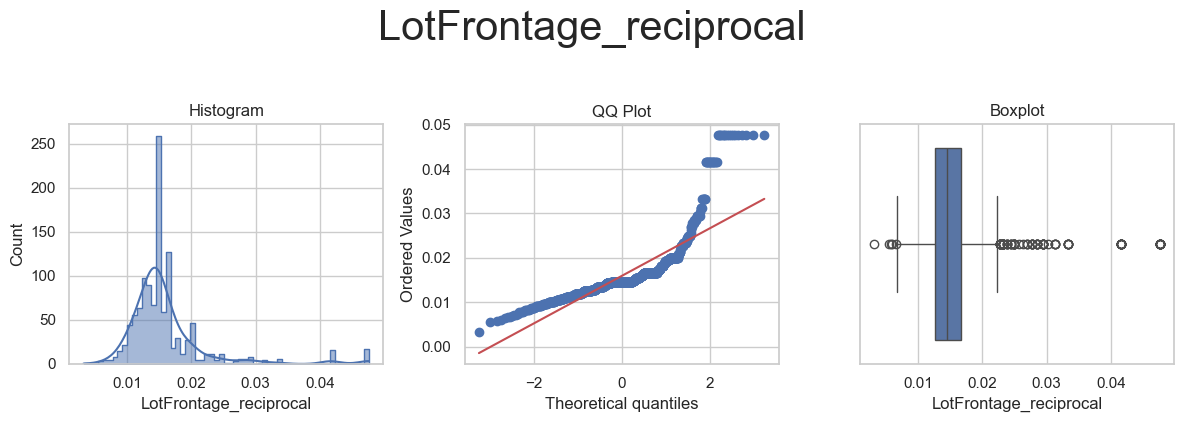

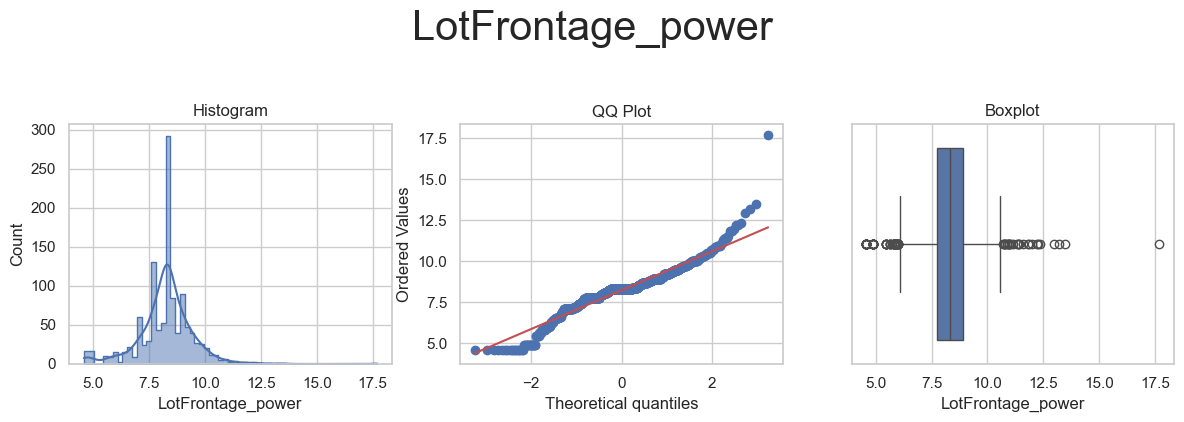

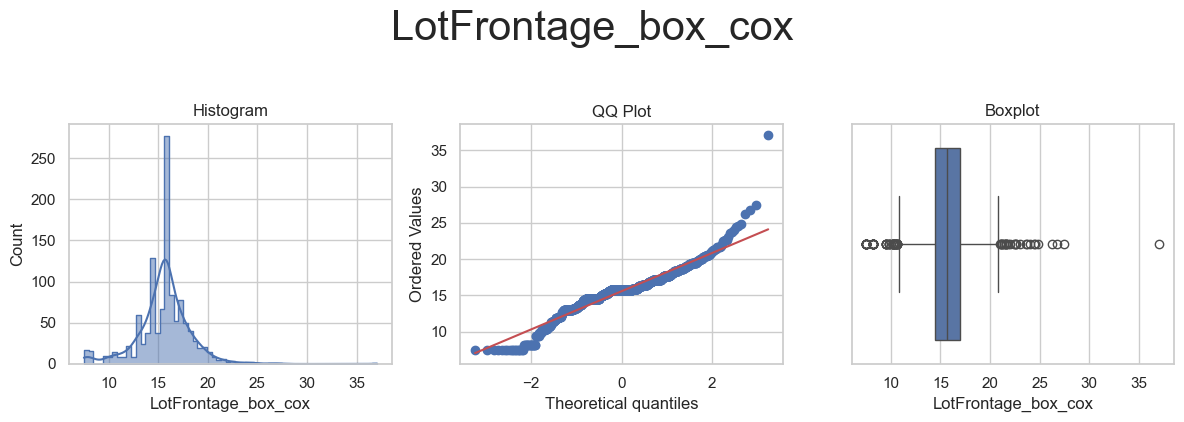

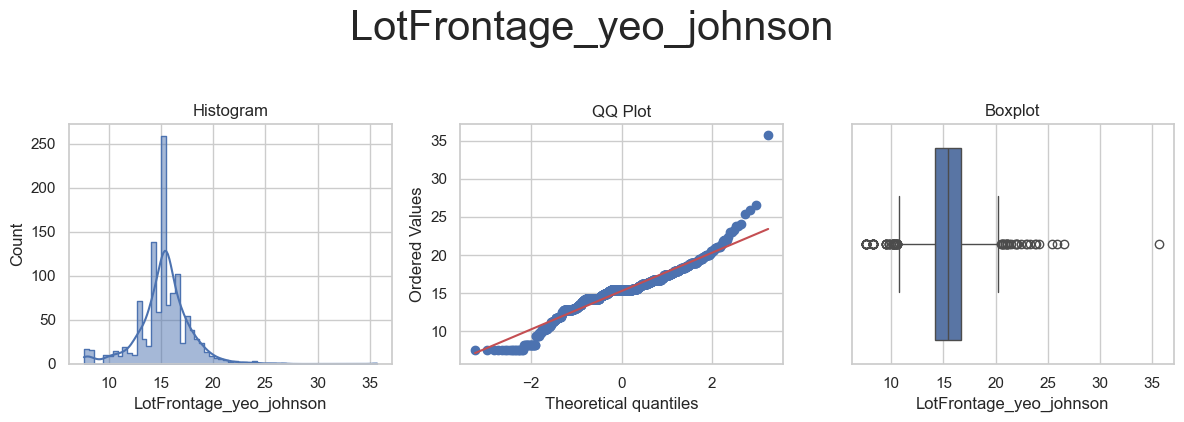



* Variable Analyzed: MasVnrArea
* Applied transformation: ['MasVnrArea_power', 'MasVnrArea_yeo_johnson'] 



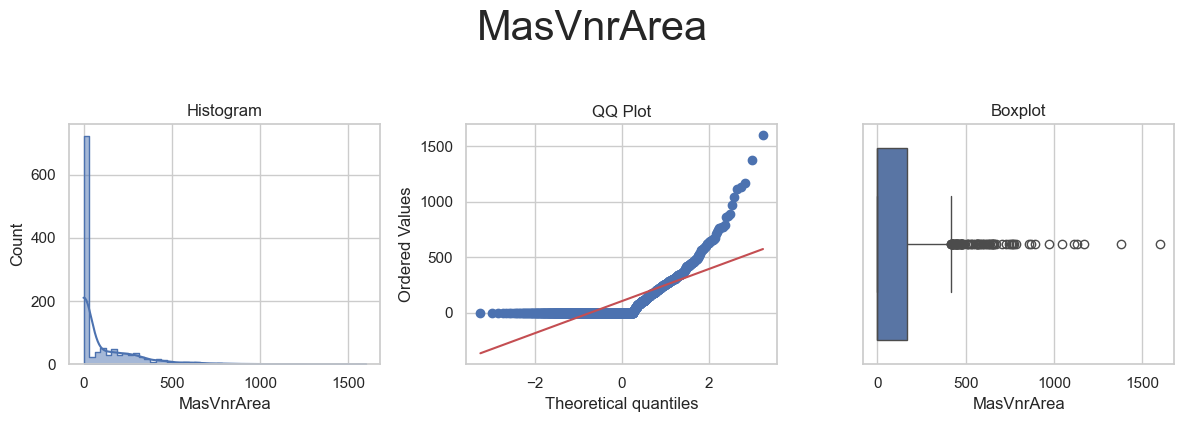

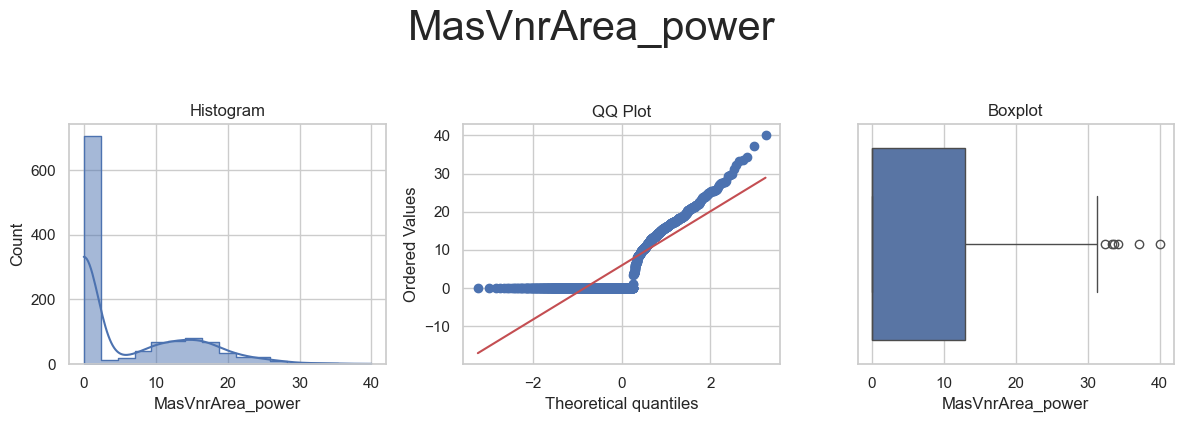

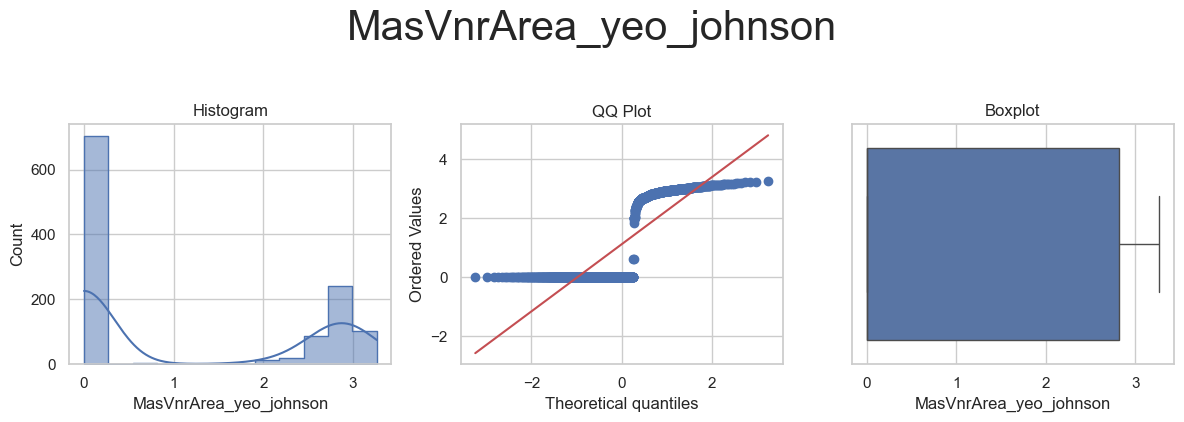



* Variable Analyzed: BsmtFinSF1
* Applied transformation: ['BsmtFinSF1_power', 'BsmtFinSF1_yeo_johnson'] 



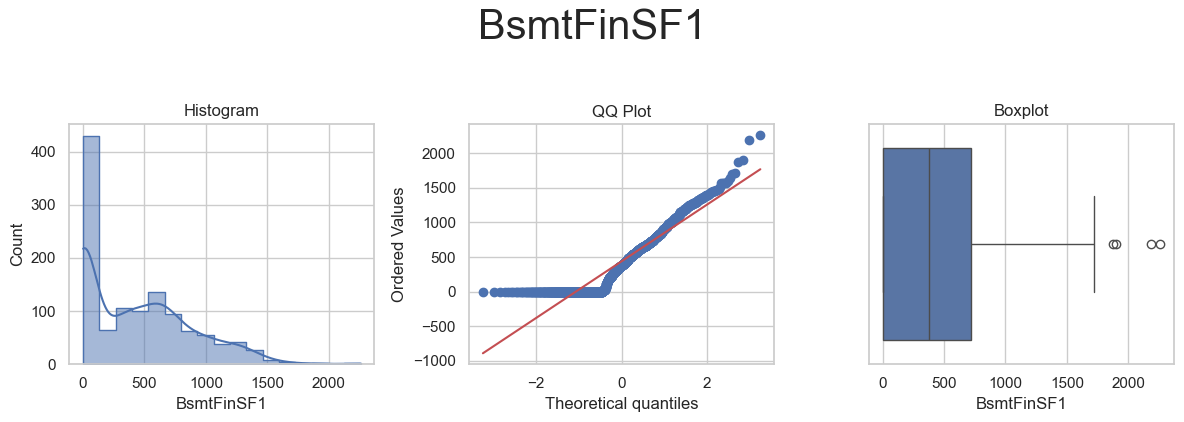

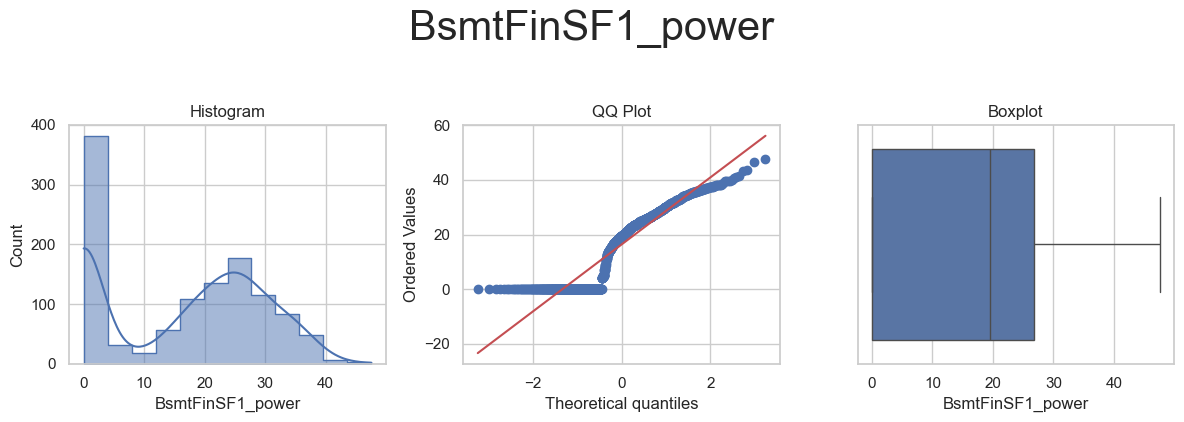

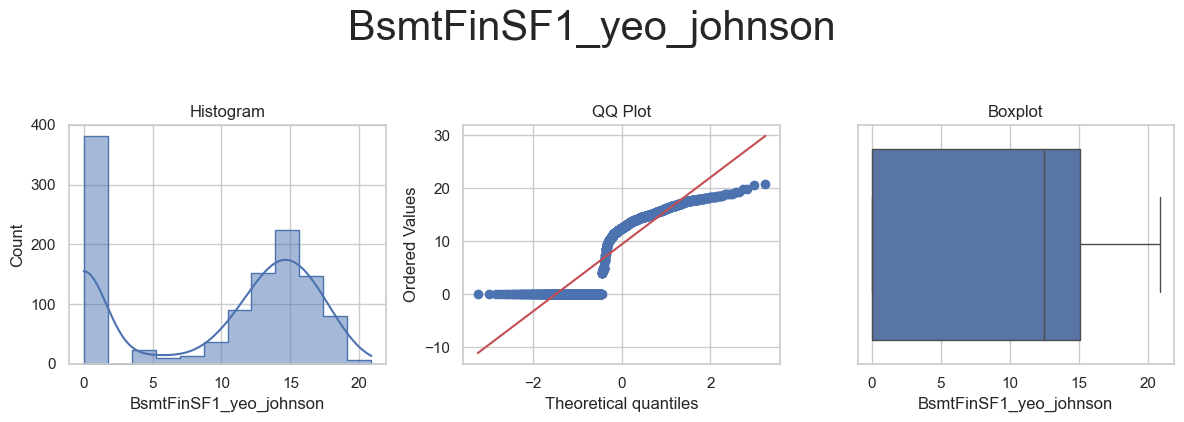



* Variable Analyzed: OpenPorchSF
* Applied transformation: ['OpenPorchSF_power', 'OpenPorchSF_yeo_johnson'] 



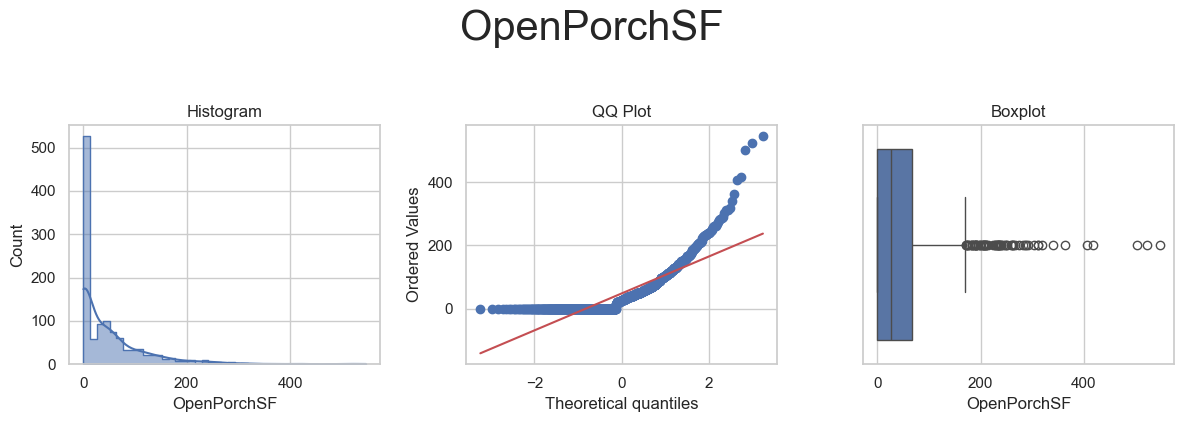

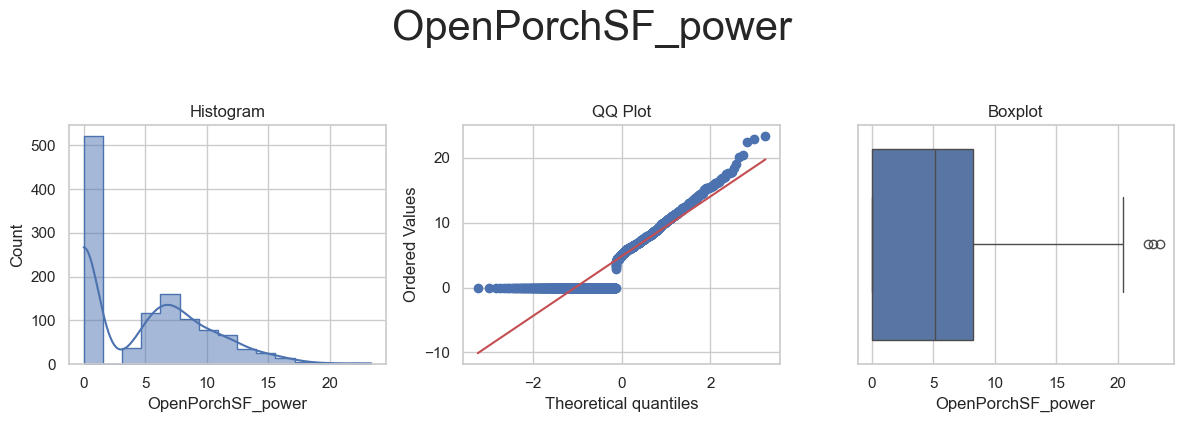

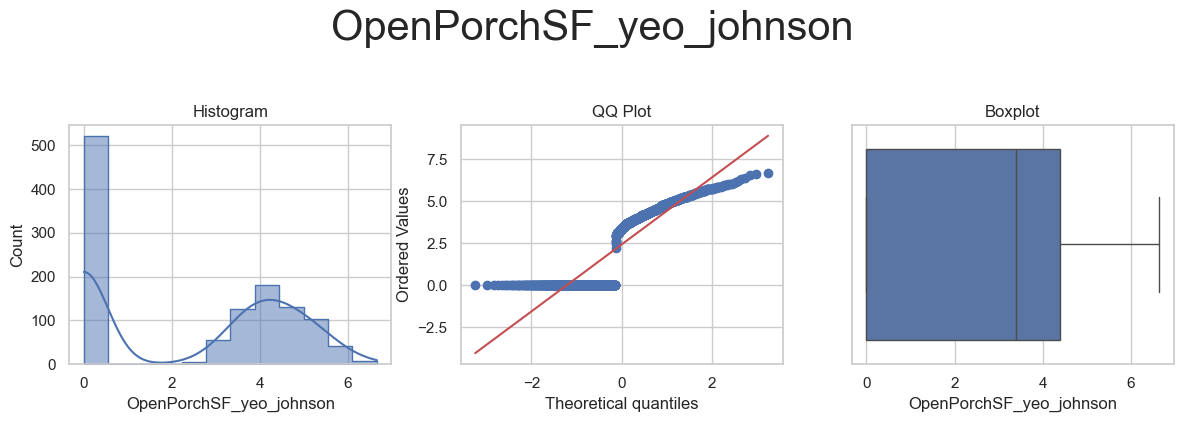

In [24]:
df_engineering = FeatureEngineeringAnalysis(df=df_engineering, analysis_type='numerical')

#### Result of Feature Engineering on Numerical Features

The transformation results show that applying a `log10` transformation to `SalePrice`, `LotArea`, and `LotFrontage` significantly improves their distribution and reduces skewness, as reflected in the updated box plots. Based on these findings, we will incorporate these transformations into the final machine learning pipeline.


### SmartCorrelatedSelection Variables

SmartCorrelatedSelection helps us deal with variables that are strongly correlated with each other.

This method automatically finds pairs of features that are highly correlated (based on a pre-defined threshold) and keeps only the one that has the strongest relationship with the target variable (`SalePrice`).

To execute this, we use a function provided by Code Institute during the Walkthrough Project "Churnometer". It allows us to reduce redundancy in the dataset while keeping the most useful predictors for modeling.


In [15]:
df_engineering_smart = TrainSet.copy().drop(columns=["SalePrice"])
df_engineering_smart.head(3)

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtFinSF1,BsmtUnfSF,GarageArea,GarageYrBlt,GrLivArea,LotArea,LotFrontage,...,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,YearRemodAdd,KitchenQual_Enc,GarageFinish_Enc,BsmtExposure_Enc,BsmtFinType1_Enc
0,1828,0.0,3.0,48,1774,774,2007.0,1828,11694,90.0,...,108,5,9,1822,2007,2007,3,0.0,2.0,0.0
1,894,0.0,2.0,0,894,308,1962.0,894,6600,60.0,...,0,5,5,894,1962,1962,2,0.0,0.0,0.0
2,964,0.0,2.0,713,163,432,1921.0,964,13360,80.0,...,0,7,5,876,1921,2006,2,0.0,0.0,3.0


In [33]:
from feature_engine.selection import SmartCorrelatedSelection
corr_sel = SmartCorrelatedSelection(variables=None, method="spearman", threshold=0.6, selection_method="variance")

corr_sel.fit_transform(df_engineering_smart)
corr_sel.correlated_feature_sets_

[{'1stFlrSF', 'TotalBsmtSF'},
 {'2ndFlrSF', 'GrLivArea'},
 {'BsmtFinSF1', 'BsmtFinType1_Enc'},
 {'GarageArea', 'GarageYrBlt'},
 {'KitchenQual_Enc', 'OverallQual', 'YearBuilt'}]

In [34]:
corr_sel.features_to_drop_

['1stFlrSF',
 '2ndFlrSF',
 'GarageYrBlt',
 'OverallQual',
 'KitchenQual_Enc',
 'BsmtFinType1_Enc']

The results of the `SmartCorrelatedSelection` are somewhat contradictory and require further assessment. First of all, it suggests removing `OverallQual`, which is one of the strongest predictors of the target variable `SalePrice`. 

To address this, we will increase the correlation threshold to 0.7 and observe the resulting feature selections.




In [35]:
from feature_engine.selection import SmartCorrelatedSelection
corr_sel = SmartCorrelatedSelection(variables=None, method="spearman", threshold=0.7, selection_method="variance")

corr_sel.fit_transform(df_engineering_smart)
corr_sel.correlated_feature_sets_

[{'1stFlrSF', 'TotalBsmtSF'},
 {'BsmtFinSF1', 'BsmtFinType1_Enc'},
 {'GarageYrBlt', 'YearBuilt', 'YearRemodAdd'}]

In [36]:
corr_sel.features_to_drop_

['1stFlrSF', 'GarageYrBlt', 'YearRemodAdd', 'BsmtFinType1_Enc']

The results above have already helped us narrow down the selection. As such, based on our analysis and domain knowledge, we have decided to drop the following features as part of the ML pipeline:

- `GarageYrBlt`
- `1stFlrSF`
- `YearRemodAdd`
- `BsmtFinType1_Enc`
  

---

## Conclusion and Next Steps

- This notebook finalized the preparation of features for modeling.
- Features with weak predictive power or excessive redundancy were removed.
- Ordinal encoding was applied to selected categorical variables to preserve ranking order.
- Log transformations were applied to correct skewness in key numerical features.
- A correlation-based selection approach retained the most relevant variables while reducing multicollinearity.
- We now have a feature engineering pipeline that includes:
  - Dropping features with high missing values percentages
  - Applying ordinal encoding to categorical features
  - Applying log transformation to improve feature distribution
  - Executing SmartCorrelatedSelection to reduce high intercorrelation

The next stage will involve building and validating machine learning models using this preprocessed dataset.

